In [504]:
import pandas as pd
import numpy as np
import random
!pip install pygad

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Data visualization libraries
from collections import Counter

# Data preprocessing libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Data splitting libraries
from sklearn.model_selection import train_test_split

# Data modeling libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve   
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC 

# Ensemble methods
from mlxtend.classifier import StackingCVClassifier

In [505]:
df = pd.read_csv('/home/dev/Documents/Ml_Project/Heart Disease Prediction UCI/data/data.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [506]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [507]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [508]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [509]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [510]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [511]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [512]:
df.shape

(1025, 14)

In [513]:
for col in df.columns:
    vals = sorted(df[col].unique())
    if df[col].nunique() > 10 and df[col].dtype != 'object':
        print(f"{col}: {df[col].min()} - {df[col].max()}")
    else:
        print(f"{col}: {vals}")

age: 29 - 77
sex: [0, 1]
cp: [0, 1, 2, 3]
trestbps: 94 - 200
chol: 126 - 564
fbs: [0, 1]
restecg: [0, 1, 2]
thalach: 71 - 202
exang: [0, 1]
oldpeak: 0.0 - 6.2
slope: [0, 1, 2]
ca: [0, 1, 2, 3, 4]
thal: [0, 1, 2, 3]
target: [0, 1]


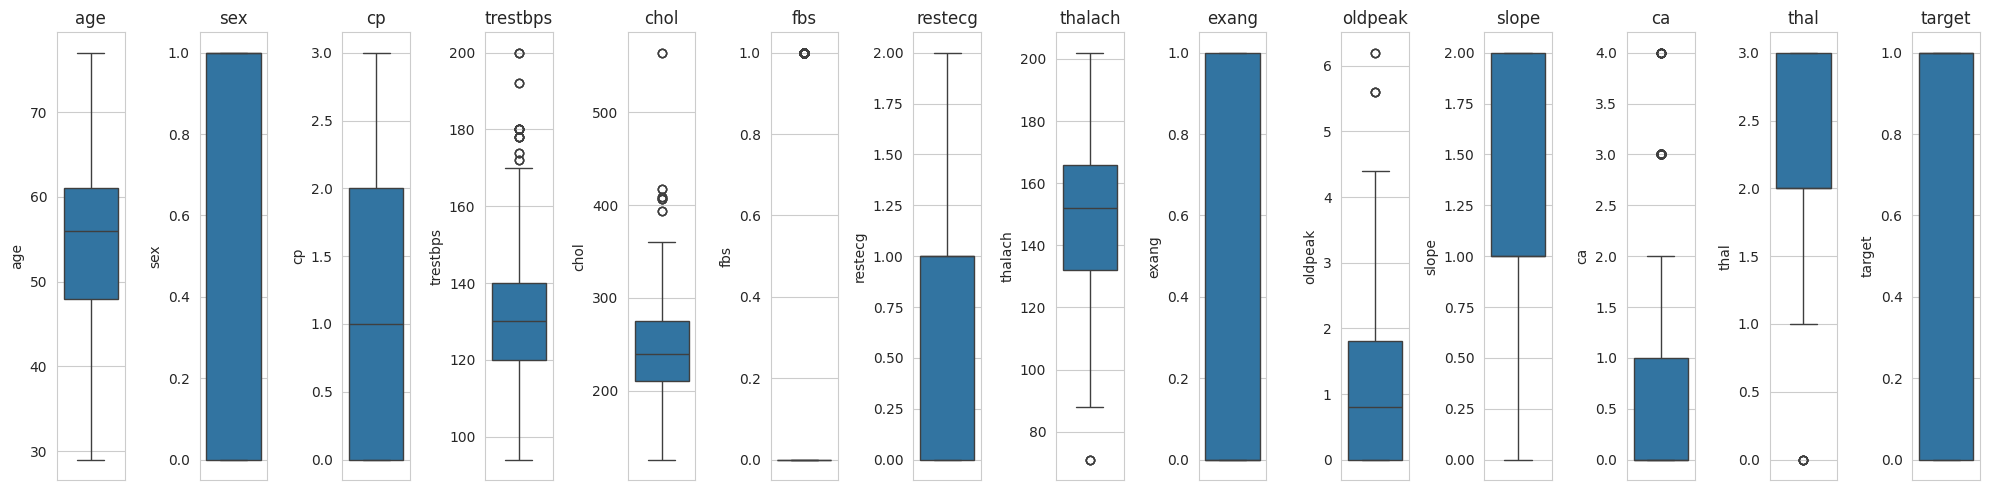

In [514]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 5))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

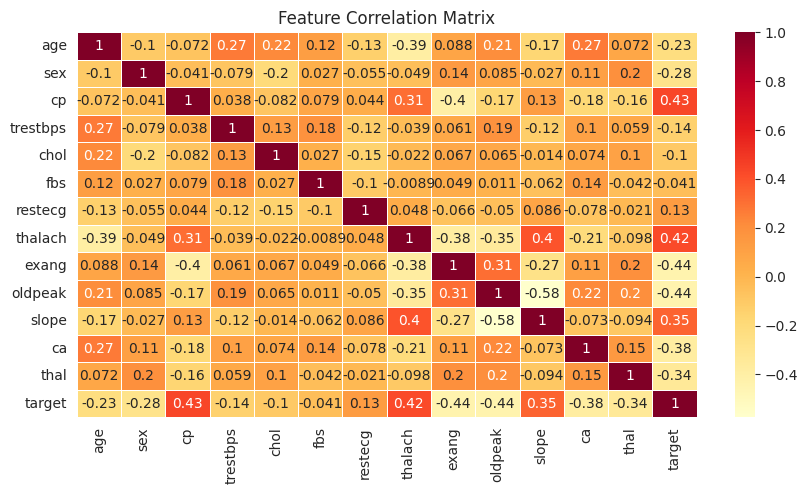

In [515]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(), annot=True, cmap='YlOrRd', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [516]:
y = df['target']
X = df.drop(columns=['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [517]:
print(y_test.unique())
Counter(y_train)

[1 0]


Counter({1: 419, 0: 401})

In [518]:
m1 = 'Logistic  Regression'
lr = LogisticRegression()
model = lr.fit(X_train, y_train)
lr_predict = lr.predict(X_test)
lr_conf_matrix = confusion_matrix(y_test, lr_predict)
lr_acc_score = accuracy_score(y_test, lr_predict)
print("Confusion matrix")
print(lr_conf_matrix)
print("\n")
print(f"Accuracy of {m1} model: {lr_acc_score*100: .2f}%\n")
print(classification_report(y_test, lr_predict))

Confusion matrix
[[ 77  21]
 [  7 100]]


Accuracy of Logistic  Regression model:  86.34%

              precision    recall  f1-score   support

           0       0.92      0.79      0.85        98
           1       0.83      0.93      0.88       107

    accuracy                           0.86       205
   macro avg       0.87      0.86      0.86       205
weighted avg       0.87      0.86      0.86       205



In [519]:
m2 = 'Naive Bayes'
nb = GaussianNB()
nb.fit(X_train, y_train)
nbpred = nb.predict(X_test)
nb_conf_matrix = confusion_matrix(y_test, nbpred)
nb_acc_score = accuracy_score(y_test, nbpred)
print("Confusion matrix")
print(nb_conf_matrix)
print("\n")
print(f"Accuracy of {m2} model: {nb_acc_score*100: .2f}%\n")
print(classification_report(y_test, nbpred))

Confusion matrix
[[79 19]
 [11 96]]


Accuracy of Naive Bayes model:  85.37%

              precision    recall  f1-score   support

           0       0.88      0.81      0.84        98
           1       0.83      0.90      0.86       107

    accuracy                           0.85       205
   macro avg       0.86      0.85      0.85       205
weighted avg       0.86      0.85      0.85       205



In [520]:
m3 ="Random Forest Classifier"
rf = RandomForestClassifier(n_estimators=20, random_state=2, max_depth=5)
rf.fit(X_train, y_train)
rf_predicted = rf.predict(X_test)
rf_conf_matrix = confusion_matrix(y_test, rf_predicted)
rf_acc_score = accuracy_score(y_test, rf_predicted)
print("Confusion matrix")
print(rf_conf_matrix)
print("\n")
print(f"Accuracy of {m3} model: {rf_acc_score*100: .2f}%\n")
print(classification_report(y_test, rf_predicted))

Confusion matrix
[[ 89   9]
 [  2 105]]


Accuracy of Random Forest Classifier model:  94.63%

              precision    recall  f1-score   support

           0       0.98      0.91      0.94        98
           1       0.92      0.98      0.95       107

    accuracy                           0.95       205
   macro avg       0.95      0.94      0.95       205
weighted avg       0.95      0.95      0.95       205



In [521]:
m4 = "Extreme Gradient Boosting"
xgb = XGBClassifier(learning_rate=0.01, n_estimators=25, max_depth=15, gamma=0.6, subsample=0.52, colsample_bytree=0.6, seed=27, reg_lambda=2, booster='dart', colsample_bylevel=0.6, colsample_bynode=0.6)
xgb.fit(X_train, y_train)
xgb_predicted = xgb.predict(X_test)
xgb_conf_matrix = confusion_matrix(y_test, xgb_predicted)
xgb_acc_score = accuracy_score(y_test, xgb_predicted)
print("Confusion matrix")
print(xgb_conf_matrix)
print("\n")
print(f"Accuracy of {m4} model: {xgb_acc_score*100: .2f}%\n")
print(classification_report(y_test, xgb_predicted)) 

Confusion matrix
[[ 80  18]
 [  6 101]]


Accuracy of Extreme Gradient Boosting model:  88.29%

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        98
           1       0.85      0.94      0.89       107

    accuracy                           0.88       205
   macro avg       0.89      0.88      0.88       205
weighted avg       0.89      0.88      0.88       205



In [522]:
m5 = "K-NeighborsClassifier"
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
knn_predicted = knn.predict(X_test)
knn_conf_matrix = confusion_matrix(y_test, knn_predicted)
knn_acc_score = accuracy_score(y_test, knn_predicted)
print("Confusion matrix")
print(knn_conf_matrix)
print("\n")
print(f"Accuracy of {m5} model: {knn_acc_score*100: .2f}%\n")
print(classification_report(y_test, knn_predicted)) 

Confusion matrix
[[84 14]
 [11 96]]


Accuracy of K-NeighborsClassifier model:  87.80%

              precision    recall  f1-score   support

           0       0.88      0.86      0.87        98
           1       0.87      0.90      0.88       107

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205



In [523]:
m6 = "Decision Tree Classifier"
dt = DecisionTreeClassifier(max_depth=6, random_state=0, criterion='entropy')
dt.fit(X_train, y_train)
dt_predicted = dt.predict(X_test)
dt_conf_matrix = confusion_matrix(y_test, dt_predicted)
dt_acc_score = accuracy_score(y_test, dt_predicted)
print("Confusion matrix")
print(dt_conf_matrix)
print("\n")
print(f"Accuracy of {m6} model: {dt_acc_score*100: .2f}%\n")
print(classification_report(y_test, dt_predicted))

Confusion matrix
[[95  3]
 [ 8 99]]


Accuracy of Decision Tree Classifier model:  94.63%

              precision    recall  f1-score   support

           0       0.92      0.97      0.95        98
           1       0.97      0.93      0.95       107

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



In [524]:
m7 = "Support Vector Classifier"
svc = SVC(kernel='rbf', C=2)
svc.fit(X_train, y_train)
svc_predicted = svc.predict(X_test)
svc_conf_matrix = confusion_matrix(y_test, svc_predicted)
svc_acc_score = accuracy_score(y_test, svc_predicted)
print("Confusion matrix")
print(svc_conf_matrix)
print("\n")
print(f"Accuracy of {m7} model: {svc_acc_score*100: .2f}%\n")
print(classification_report(y_test, svc_predicted))

Confusion matrix
[[ 94   4]
 [  0 107]]


Accuracy of Support Vector Classifier model:  98.05%

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        98
           1       0.96      1.00      0.98       107

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



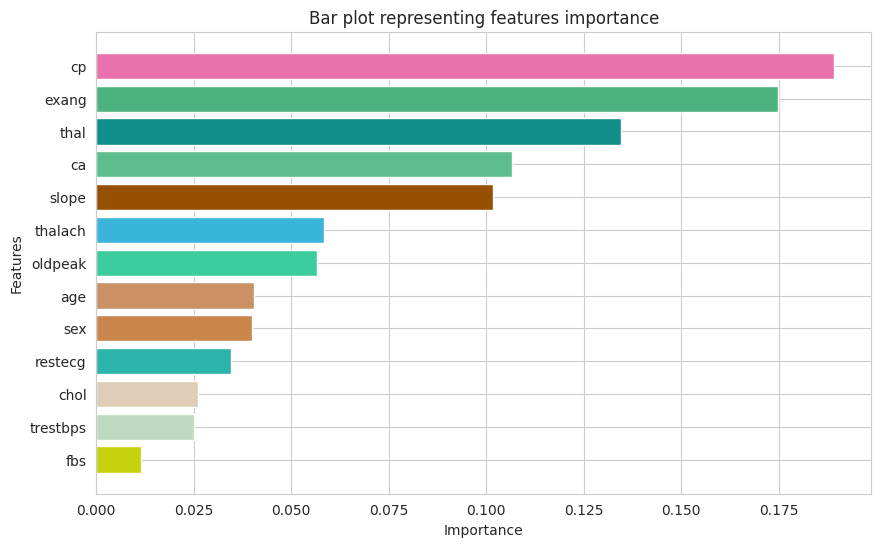

In [525]:
import matplotlib.pyplot as plt
import random

imp_feature = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

imp_feature = imp_feature.sort_values(by='Importance', ascending=True)
random_colors = ['#%06X' % random.randint(0, 0xFFFFFF) for _ in range(len(imp_feature))]

plt.figure(figsize=(10, 6))
plt.title('Bar plot representing features importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.barh(imp_feature['Feature'], imp_feature['Importance'], color=random_colors)
plt.show()

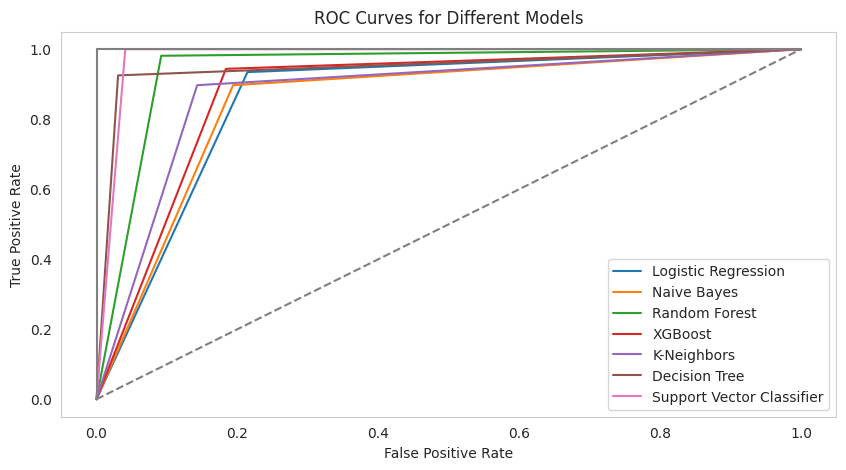

In [526]:
lr_false_positive_rate, lr_true_positive_rate, lr_thresholds = roc_curve(y_test, lr_predict)
nb_false_positive_rate, nb_true_positive_rate, nb_thresholds = roc_curve(y_test, nbpred)
rf_false_positive_rate, rf_true_positive_rate, rf_thresholds = roc_curve(y_test, rf_predicted)
xgb_false_positive_rate, xgb_true_positive_rate, xgb_thresholds = roc_curve(y_test, xgb_predicted)
knn_false_positive_rate, knn_true_positive_rate, knn_thresholds = roc_curve(y_test, knn_predicted)
dt_false_positive_rate, dt_true_positive_rate, dt_thresholds = roc_curve(y_test, dt_predicted)
svc_false_positive_rate, svc_true_positive_rate, svc_thresholds = roc_curve(y_test, svc_predicted)

sns.set_style('whitegrid')
plt.figure(figsize=(10, 5))
plt.title('ROC Curves for Different Models')
plt.plot(lr_false_positive_rate, lr_true_positive_rate, label='Logistic Regression')
plt.plot(nb_false_positive_rate, nb_true_positive_rate, label='Naive Bayes')
plt.plot(rf_false_positive_rate, rf_true_positive_rate, label='Random Forest') 
plt.plot(xgb_false_positive_rate, xgb_true_positive_rate, label='XGBoost')
plt.plot(knn_false_positive_rate, knn_true_positive_rate, label='K-Neighbors')
plt.plot(dt_false_positive_rate, dt_true_positive_rate, label='Decision Tree')
plt.plot(svc_false_positive_rate, svc_true_positive_rate, label='Support Vector Classifier')
plt.plot([0,1],ls='--')
plt.plot([0, 0], [1, 0], c='.5')
plt.plot([1,1],c='.5')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()


In [527]:
model_results = pd.DataFrame({'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'XGBoost', 'K-Neighbors', 'Decision Tree', 'Support Vector Classifier'],'Accuracy': [lr_acc_score*100, nb_acc_score*100, rf_acc_score*100, xgb_acc_score*100, knn_acc_score*100, dt_acc_score*100, svc_acc_score*100]})

model_results['Accuracy'] = model_results['Accuracy'].apply(lambda x: f"{x:.2f}%")
print(model_results)

                       Model Accuracy
0        Logistic Regression   86.34%
1                Naive Bayes   85.37%
2              Random Forest   94.63%
3                    XGBoost   88.29%
4                K-Neighbors   87.80%
5              Decision Tree   94.63%
6  Support Vector Classifier   98.05%


In [528]:
scv = StackingCVClassifier(classifiers=[svc, dt, knn], meta_classifier= svc, random_state=42)
scv.fit(X_train, y_train)
scv_predicted = scv.predict(X_test)
scv_conf_matrix = confusion_matrix(y_test, scv_predicted)
scv_acc_score1 = accuracy_score(y_test, scv_predicted)
print("Confusion matrix")
print(scv_conf_matrix)
print("\n")     
print(f"Accuracy of Stacking Classifier model: {scv_acc_score1*100: .2f}%\n")
print(classification_report(y_test, scv_predicted))

Confusion matrix
[[97  1]
 [ 8 99]]


Accuracy of Stacking Classifier model:  95.61%

              precision    recall  f1-score   support

           0       0.92      0.99      0.96        98
           1       0.99      0.93      0.96       107

    accuracy                           0.96       205
   macro avg       0.96      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205

